First we need to read in some packages that we will need later. With the help of these packages we can e.g. read the data and create graphs.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

print('imported all modules')

imported all modules


Then we define some functions of our own.

In [2]:
### Read out leptons from csv
def ReadLeptons(data, event):
  lepton1 = np.array([ data.values[event][0], data.values[event][1], data.values[event][2], data.values[event][3] ])
  lepton2 = np.array([ data.values[event][4], data.values[event][5], data.values[event][6], data.values[event][7] ])
  lepton3 = np.array([ data.values[event][8], data.values[event][9], data.values[event][10], data.values[event][11] ])
  lepton4 = np.array([ data.values[event][12], data.values[event][13], data.values[event][14], data.values[event][15] ])
  return [ lepton1, lepton2, lepton3, lepton4 ]

### Read out event weight from csv
def ReadWeight(data, event):
  return data.values[event][16]

### Calculate energy of particles
def Energy(p):
  return p[3]

### calculate the pT of particles
def Pt(p):
  pt = math.sqrt( p[0]*p[0] + p[1]*p[1] )
  return pt

### Mcalculate the mass of particles
def Mass(p):
  mass = 0
  '''
  here you need to calculate the mass
  The formula is:
  m2 = - px*px - py*py - pz*pz + E*E

  If m2 > 0, you can take the root:
  mass = math.sqrt( m2 )

  If m2 < 0, we should set the value to 0:
  mass = 0
  '''
  return mass


### function to draw graphs
def plot(nbins, min, max, datavalues, mcvalues, mcweights, mcnames, xlabel):
  fig = plt.figure()
  fig.subplots_adjust()
  ax1 = fig.add_subplot()
  ax1.set_ylabel('Events')
  ax1.set_xlabel(xlabel)
  plt.hist( mcvalues, weights = mcweights , bins=nbins, range=(min,max), label=mcnames, stacked=True )
  datahist,bins = np.histogram(datavalues, bins=nbins, range=(min,max))
  binsize = (max-min)/nbins
  real_bins = [x+binsize/2 for x in bins]
  del real_bins[-1]
  yerror = [math.sqrt(x) for x in datahist]
  xerror = [binsize/2 for x in datahist]
  plt.errorbar( real_bins, datahist, yerr=yerror, xerr=xerror, label="Data", fmt='o', color="black" )
  plt.legend(loc="upper right")
  plt.show()

### Print function to see the progress of the read out
def PrintProgress(event, Nevents):
  percentage = PrintProgress.counter*0.2
  if event > percentage*Nevents:
    print('   - ',int(percentage*100),'% (',event, 'of', Nevents, 'events processed)')
    PrintProgress.counter += 1
  if event == Nevents-1:
    PrintProgress.counter = 0
PrintProgress.counter = 0

def get_totals(data, mcvalues, mcweights, range):
  h_data = np.histogram(data, bins=2, range=range)
  h_signal = np.histogram(mcvalues[0], bins=2, range=range, weights=mcweights[0])
  h_bkg = np.histogram(mcvalues[1], bins=2, range=range, weights=mcweights[1])
  return h_data, h_signal, h_bkg

pathtocsv = 'https://raw.githubusercontent.com/abenecke/PPT_csv/master/'

print('defined all functions and variables')

defined all functions and variables


Now we read in the data. The data are stored [here]() in a csv format and we can read them out from there.

<div>
  <center>
    <img src="https://raw.githubusercontent.com/abenecke/PPT_csv/master/CSV.png" width="500"/>
  </center>
</div>



In [3]:
### Readout of the data
LepEnergyData = []
LepPtData = []

### data files that we readout, at the moment only data from 2011 and 2012 in the electron and muon channel
Datafiles = [
             'DATA_Electron_2011.csv',
             'DATA_Muon_2011.csv',
             'DATA_Electron_2012.csv',
             'DATA_Muon_2012.csv'
]
for filename in Datafiles:
  print('start with', filename)
  csvdata = pd.read_csv(pathtocsv+filename, header=None)
  Nevents = len(csvdata)
  for event in range(Nevents):
    PrintProgress(event,Nevents)

    ### Here the analysis code begins: for each event in the csv file the following code is executed
    Leptons = ReadLeptons(csvdata, event)


    energy = Energy(Leptons[0]) ### get the energy of the first lepton in the event
    pt = Pt(Leptons[0]) ### get the pT of the first lepton in the event
    LepEnergyData.append(energy) ### store the energy of the first lepton of each event
    LepPtData.append(pt) ### store the pT of the first lepton of each event


    #########

  print('   - done')


start with DATA_Electron_2011.csv
   -  0 % ( 1 of 7 events processed)
   -  20 % ( 2 of 7 events processed)
   -  40 % ( 3 of 7 events processed)
   -  60 % ( 5 of 7 events processed)
   -  80 % ( 6 of 7 events processed)
   - done
start with DATA_Muon_2011.csv
   -  0 % ( 1 of 31 events processed)
   -  20 % ( 7 of 31 events processed)
   -  40 % ( 13 of 31 events processed)
   -  60 % ( 19 of 31 events processed)
   -  80 % ( 25 of 31 events processed)
   - done
start with DATA_Electron_2012.csv
   -  0 % ( 1 of 41 events processed)
   -  20 % ( 9 of 41 events processed)
   -  40 % ( 17 of 41 events processed)
   -  60 % ( 25 of 41 events processed)
   -  80 % ( 33 of 41 events processed)
   - done
start with DATA_Muon_2012.csv
   -  0 % ( 1 of 199 events processed)
   -  20 % ( 40 of 199 events processed)
   -  40 % ( 80 of 199 events processed)
   -  60 % ( 120 of 199 events processed)
   -  80 % ( 160 of 199 events processed)
   - done


Now we readout simulated events of the process ZZ->4l, which are background events for our analysis.
<div>
  <center>
    <img src="https://raw.githubusercontent.com/abenecke/PPT_csv/master//ZZ.png" width="400"/>
  </center>
</div>



In [4]:
### Readout of ZZ simulated background events
LepEnergyZZ = []
LepPtZZ = []
WeightsZZ = []


ZZfiles = [
### insert all MC_ZZ*.csv files you can find: https://github.com/abenecke/PPT_csv
]
for filename in ZZfiles:
  print('start with', filename)
  csvdata = pd.read_csv(pathtocsv+filename, header=None)
  Nevents = len(csvdata)
  for event in range(Nevents):
    PrintProgress(event, Nevents)

    ### Here the analysis code beginns
    Leptons = ReadLeptons(csvdata, event)
    weight = ReadWeight(csvdata, event) ### event weight needed for simulated events only
    WeightsZZ.append(weight) ### store all event weights

    energy = Energy(Leptons[0])
    pt = Pt(Leptons[0])
    LepEnergyZZ.append(energy)
    LepPtZZ.append(pt)
    #########


  print('   - done')

Now we readout the simulated signal events: Higgs->4l.

<div>
  <center>
    <img src="https://raw.githubusercontent.com/abenecke/PPT_csv/master/Higgs4l.png" width="400"/>
  </center>
</div>

In [6]:
### Readout of Higgs simulated events (signal)
LepEnergyHiggs = []
LepPtHiggs = []
WeightsHiggs = []

Higgsfiles = [
### insert all MC_ZZ*.csv files you can find: https://github.com/abenecke/PPT_csv
]
for filename in Higgsfiles:
  print('start with', filename)
  csvdata = pd.read_csv(pathtocsv+filename, header=None)
  Nevents = len(csvdata)
  for event in range(Nevents):
    PrintProgress(event, Nevents)

    ### Here the analysis code begins:
    Leptons = ReadLeptons(csvdata, event)
    weight = ReadWeight(csvdata, event)
    # You need to fill the same kind of variables as for the ZZ background



    #########

  print('   - done')

Now we need to create the histograms with the function defined above: 'plot'. This function needs the following arguments:

*   nbins: number of bins
*   min: minimum
*   max: maximum
*   data: list of the values in data
*   mcdatalist: list of values Liste der Messwerte in Simulation
*   weights: list of weights in simulation
*   labels: list of labels for simulation
*   xlabel: titles of the x-axes

`plot(nbins, min, max, data, mcdatalist, weights, labels, xlabel)`



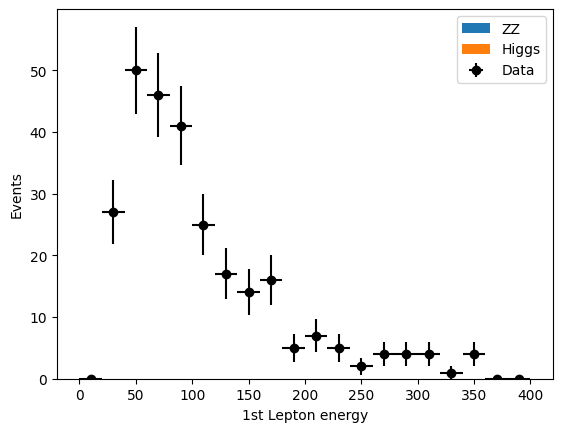

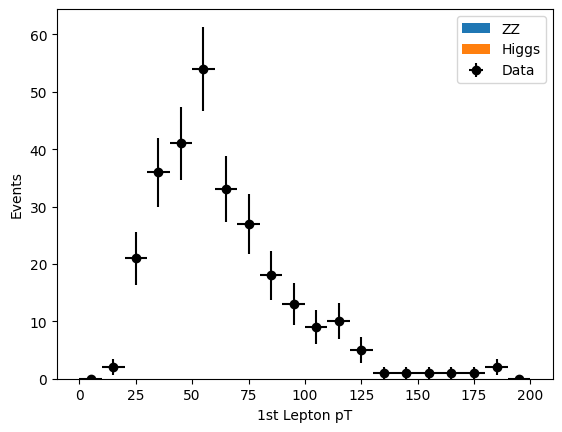

In [6]:
### two example histograms
plot(20, 0, 400, LepEnergyData, [LepEnergyZZ, LepEnergyHiggs], [ WeightsZZ, WeightsHiggs] , [ 'ZZ', 'Higgs' ], '1st Lepton energy')
plot(20, 0, 200, LepPtData, [LepPtZZ, LepPtHiggs], [ WeightsZZ, WeightsHiggs] , [ 'ZZ', 'Higgs' ], '1st Lepton pT')




# Signal Significance

We can do some analysis to study how significant the signal is compared to the background. One method is to check a quantity known as the signal significance $S$, which is defined by
$$S = \frac{N_\mathrm{sig}}{N_\mathrm{bkg}}$$
where $N_\mathrm{sig}$ and $N_\mathrm{bkg}$ are the number of signal and background points respectively. A larger  represents a better signal-to-background ratio, and a more significant signal peak. 

In [ ]:
# Add the invariant mass distribution to this function
data = None # What should go here? 
signal = None # What should go here? 
bkg = None # What should go here? 
mcweights = [WeightsZZ, WeightsHiggs]
data, signal, bkg = get_totals(data, [signal, bkg], mcweights, range=(0,0)) 

def significance(data, signal, bkg):
    sig = 0
    """
    hear you need to calculate the significance
    """
    return sig

sig = significance(data, signal, bkg)

print(f"Observed Significance: {sig:.2f}")